<a href="https://colab.research.google.com/github/Reva694/rawuh-model/blob/main/Analisi_Deskriptif%2CBivariat%2CMultivariat_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path = "/content/drive/MyDrive/dataset PAK/"

# Analisi Deskriptif

--- HASIL ANALISIS DETAIL: DEMOGRAFI ---
Rata-rata Usia    : 54.18 tahun
Median Usia       : 55.0 tahun
Pekerjaan Terbanyak: IRT
Proporsi Gender   :
Jenis_Kelamin
Laki-laki    50.0
Perempuan    50.0
Name: proportion, dtype: float64
----------------------------------------


/tmp/ipykernel_4608/3837540956.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Jenis_Kelamin', data=df_demo, ax=axes[1], palette='pastel')
/tmp/ipykernel_4608/3837540956.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Pekerjaan', data=df_demo, ax=axes[2], palette='viridis', order=df_demo['Pekerjaan'].value_counts().index)


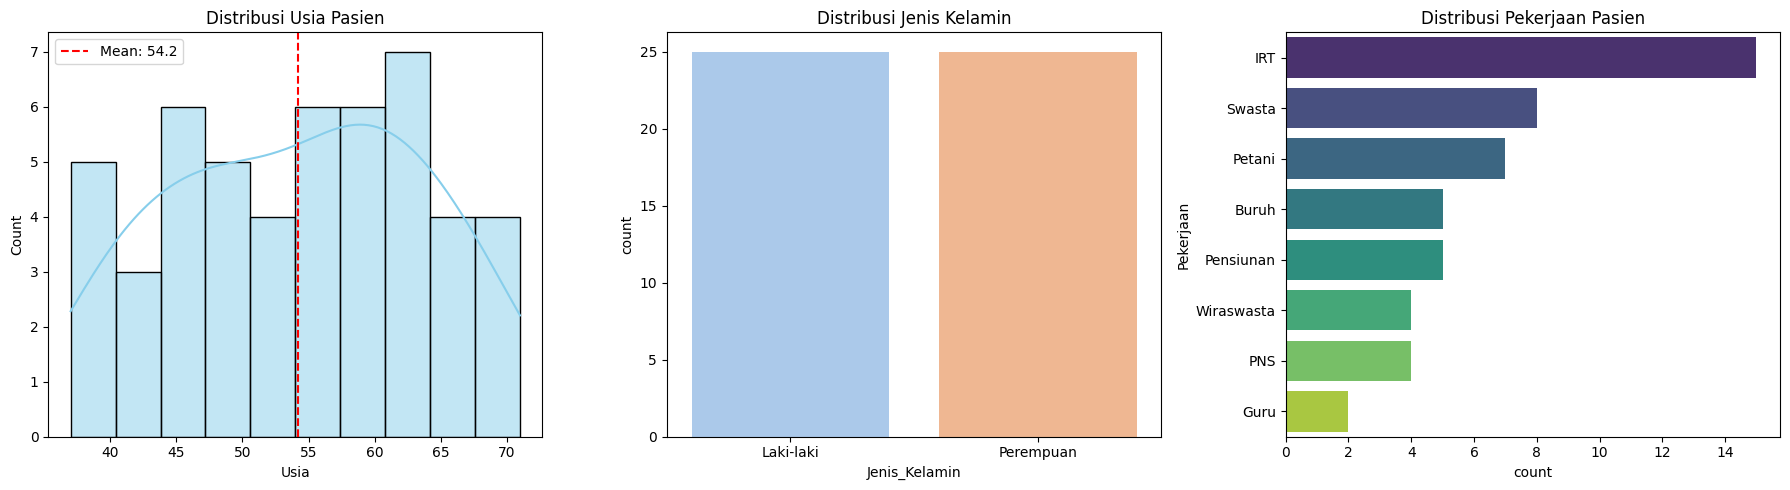

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df_demo = pd.read_csv(path + "demografi_pasien.csv")

# 2. Perhitungan Statistik Deskriptif
mean_usia = df_demo['Usia'].mean()
median_usia = df_demo['Usia'].median()
mode_pekerjaan = df_demo['Pekerjaan'].mode()[0]
proporsi_gender = df_demo['Jenis_Kelamin'].value_counts(normalize=True) * 100

print(f"--- HASIL ANALISIS DETAIL: DEMOGRAFI ---")
print(f"Rata-rata Usia    : {mean_usia:.2f} tahun")
print(f"Median Usia       : {median_usia} tahun")
print(f"Pekerjaan Terbanyak: {mode_pekerjaan}")
print(f"Proporsi Gender   :\n{proporsi_gender}")
print(f"----------------------------------------")

# 3. Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Distribusi Usia (Histogram)
sns.histplot(df_demo['Usia'], bins=10, kde=True, ax=axes[0], color='skyblue')
axes[0].axvline(mean_usia, color='red', linestyle='--', label=f'Mean: {mean_usia:.1f}')
axes[0].set_title('Distribusi Usia Pasien')
axes[0].legend()

# Plot B: Jenis Kelamin (Bar Chart)
sns.countplot(x='Jenis_Kelamin', data=df_demo, ax=axes[1], palette='pastel')
axes[1].set_title('Distribusi Jenis Kelamin')

# Plot C: Pekerjaan (Bar Chart Horizontal)
sns.countplot(y='Pekerjaan', data=df_demo, ax=axes[2], palette='viridis', order=df_demo['Pekerjaan'].value_counts().index)
axes[2].set_title('Distribusi Pekerjaan Pasien')

plt.tight_layout()
plt.show()

#Aalisis Bivariat

/tmp/ipykernel_4608/1130826471.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  ax = sns.barplot(x='Jenis_Kelamin', y='Sistolik_Awal', data=df, palette='magma', ci=95)
/tmp/ipykernel_4608/1130826471.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Jenis_Kelamin', y='Sistolik_Awal', data=df, palette='magma', ci=95)


Hasil P-Value: 0.3679


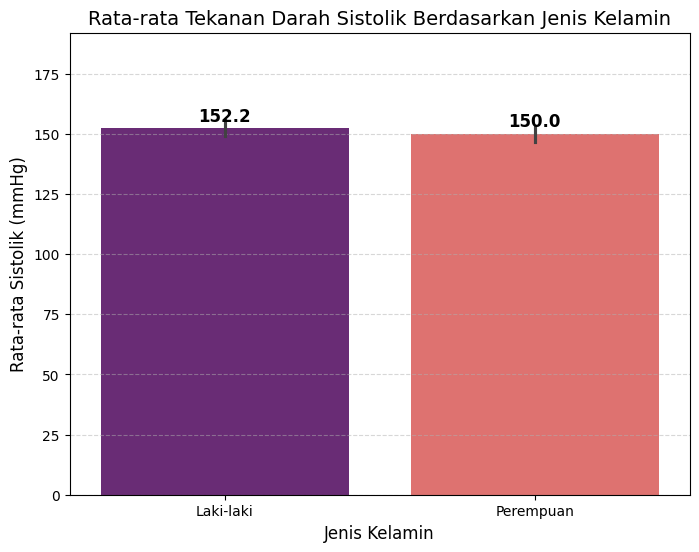

=== HASIL UJI T-TEST BIVARIAT ===
Rata-rata TD Laki-laki : 152.20 mmHg
Rata-rata TD Perempuan : 149.96 mmHg
P-Value                : 0.3679
---------------------------------
Kesimpulan: Tidak ada perbedaan signifikan (perbedaan hanya karena faktor kebetulan).

=== HASIL UJI CHI-SQUARE (Kategorik vs Kategorik) ===
Variabel: Merokok vs Diagnosis
Chi-Square Statistic: 35.9347
P-Value Chi-Square  : 0.0000
Kesimpulan: Ada hubungan signifikan antara status merokok dengan tingkat keparahan diagnosis.


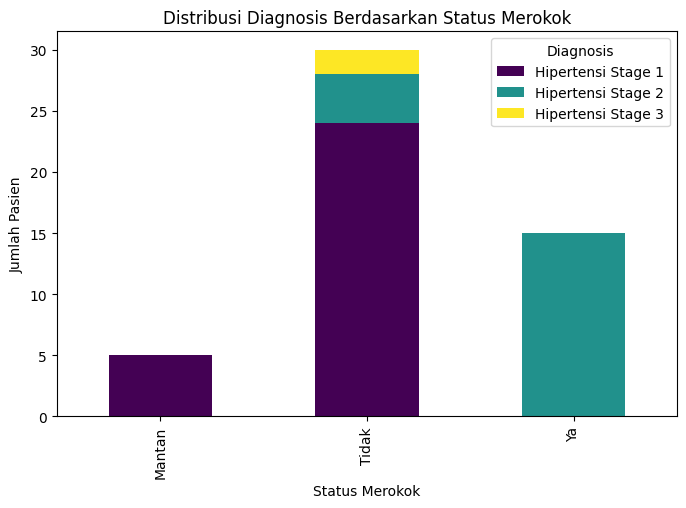


=== HASIL UJI ANOVA (Numerik vs >2 Kelompok) ===
Variabel: Aktivitas Fisik vs Sistolik Awal
F-Statistic: 130.2284
P-Value ANOVA: 0.0000
Kesimpulan: Ada perbedaan rata-rata tekanan darah yang signifikan berdasarkan tingkat aktivitas fisik.


/tmp/ipykernel_4608/1130826471.py:108: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  ax_anova = sns.barplot(x='Aktivitas_Fisik', y='Sistolik_Awal', data=df,
/tmp/ipykernel_4608/1130826471.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_anova = sns.barplot(x='Aktivitas_Fisik', y='Sistolik_Awal', data=df,


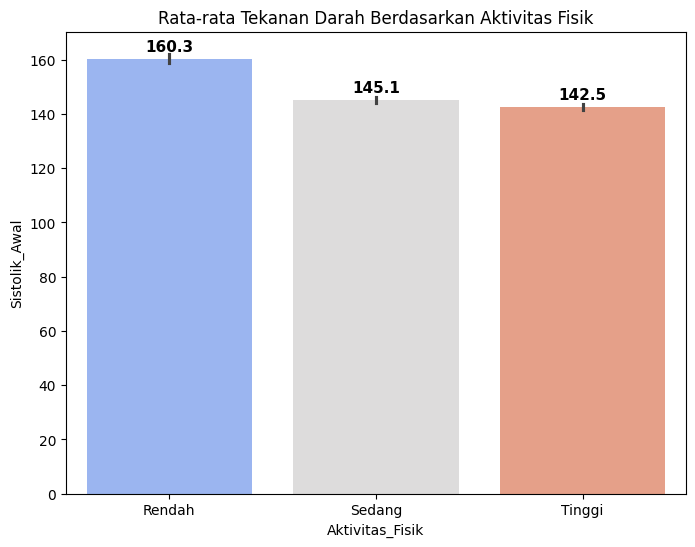

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Persiapan Data
df_demo = pd.read_csv(path + 'demografi_pasien.csv')
df_klinis = pd.read_csv(path + 'klinis_pasien.csv')
df = pd.merge(df_demo, df_klinis, on='ID_Pasien')

# Mengambil angka Sistolik
df['Sistolik_Awal'] = df['TD_Awal'].apply(lambda x: int(x.split('/')[0]))

# 2. Membuat Diagram Batang (Bar Chart)
plt.figure(figsize=(8, 6))
# ci=95 akan menampilkan garis error (standard error)
ax = sns.barplot(x='Jenis_Kelamin', y='Sistolik_Awal', data=df, palette='magma', ci=95)

# Menambahkan label angka rata-rata di atas batang
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

plt.title('Rata-rata Tekanan Darah Sistolik Berdasarkan Jenis Kelamin', fontsize=14)
plt.xlabel('Jenis Kelamin', fontsize=12)
plt.ylabel('Rata-rata Sistolik (mmHg)', fontsize=12)
plt.ylim(0, df['Sistolik_Awal'].max() + 20) # Biar grafik nggak kepotong
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 3. Uji Statistik (Tetap disertakan sebagai bukti ilmiah)
pria = df[df['Jenis_Kelamin'] == 'Laki-laki']['Sistolik_Awal']
wanita = df[df['Jenis_Kelamin'] == 'Perempuan']['Sistolik_Awal']
t_stat, p_val = stats.ttest_ind(pria, wanita)

print(f"Hasil P-Value: {p_val:.4f}")

plt.show()

# 4. Uji Statistik (Independent T-Test)
pria = df[df['Jenis_Kelamin'] == 'Laki-laki']['Sistolik_Awal']
wanita = df[df['Jenis_Kelamin'] == 'Perempuan']['Sistolik_Awal']

t_stat, p_val = stats.ttest_ind(pria, wanita)

print(f"=== HASIL UJI T-TEST BIVARIAT ===")
print(f"Rata-rata TD Laki-laki : {pria.mean():.2f} mmHg")
print(f"Rata-rata TD Perempuan : {wanita.mean():.2f} mmHg")
print(f"P-Value                : {p_val:.4f}")
print(f"---------------------------------")

if p_val < 0.05:
    print("Kesimpulan: Ada perbedaan signifikan antara tekanan darah laki-laki dan perempuan.")
else:
    print("Kesimpulan: Tidak ada perbedaan signifikan (perbedaan hanya karena faktor kebetulan).")

# 5. UJI CHI-SQUARE
# Gunakan ini untuk melihat hubungan antara dua variabel kategori
# Contoh: Apakah ada hubungan antara kebiasaan MEROKOK dengan DIAGNOSIS (Stage 1, 2, 3)?
print("\n=== HASIL UJI CHI-SQUARE (Kategorik vs Kategorik) ===")
contingency_table = pd.crosstab(df['Merokok'], df['Diagnosis'])
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Variabel: Merokok vs Diagnosis")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value Chi-Square  : {p_chi2:.4f}")

if p_chi2 < 0.05:
    print("Kesimpulan: Ada hubungan signifikan antara status merokok dengan tingkat keparahan diagnosis.")
else:
    print("Kesimpulan: Tidak ada hubungan signifikan antara status merokok dengan diagnosis.")

# Visualisasi untuk Chi-Square (Stacked Bar Chart)
contingency_table.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='viridis')
plt.title('Distribusi Diagnosis Berdasarkan Status Merokok')
plt.xlabel('Status Merokok')
plt.ylabel('Jumlah Pasien')
plt.legend(title='Diagnosis')
plt.show()


# 6. UJI ANOVA (One-Way ANOVA)
# Gunakan ini untuk membandingkan rata-rata lebih dari 2 kelompok
# Contoh: Apakah rata-rata Sistolik berbeda berdasarkan tingkat AKTIVITAS FISIK (Rendah, Sedang, Tinggi)?
print("\n=== HASIL UJI ANOVA (Numerik vs >2 Kelompok) ===")

# Kelompokkan data
rendah = df[df['Aktivitas_Fisik'] == 'Rendah']['Sistolik_Awal']
sedang = df[df['Aktivitas_Fisik'] == 'Sedang']['Sistolik_Awal']
tinggi = df[df['Aktivitas_Fisik'] == 'Tinggi']['Sistolik_Awal']

f_stat, p_anova = stats.f_oneway(rendah, sedang, tinggi)

print(f"Variabel: Aktivitas Fisik vs Sistolik Awal")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value ANOVA: {p_anova:.4f}")

if p_anova < 0.05:
    print("Kesimpulan: Ada perbedaan rata-rata tekanan darah yang signifikan berdasarkan tingkat aktivitas fisik.")
else:
    print("Kesimpulan: Tidak ada perbedaan signifikan rata-rata tekanan darah pada berbagai tingkat aktivitas fisik.")

# Visualisasi untuk ANOVA (Diagram Batang lagi sesuai permintaanmu)
plt.figure(figsize=(8, 6))
ax_anova = sns.barplot(x='Aktivitas_Fisik', y='Sistolik_Awal', data=df,
                       palette='coolwarm', order=['Rendah', 'Sedang', 'Tinggi'], ci=95)

# Tambah label angka di atas batang
for p in ax_anova.patches:
    ax_anova.annotate(f'{p.get_height():.1f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.title('Rata-rata Tekanan Darah Berdasarkan Aktivitas Fisik')
plt.show()

# Analisis Multivariat

=== HASIL ANALISIS MULTIVARIAT (REGRESI BERGANDA) ===
                            OLS Regression Results                            
Dep. Variable:          Sistolik_Awal   R-squared:                       0.934
Model:                            OLS   Adj. R-squared:                  0.928
Method:                 Least Squares   F-statistic:                     158.6
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           6.56e-26
Time:                        15:02:44   Log-Likelihood:                -110.72
No. Observations:                  50   AIC:                             231.4
Df Residuals:                      45   BIC:                             241.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

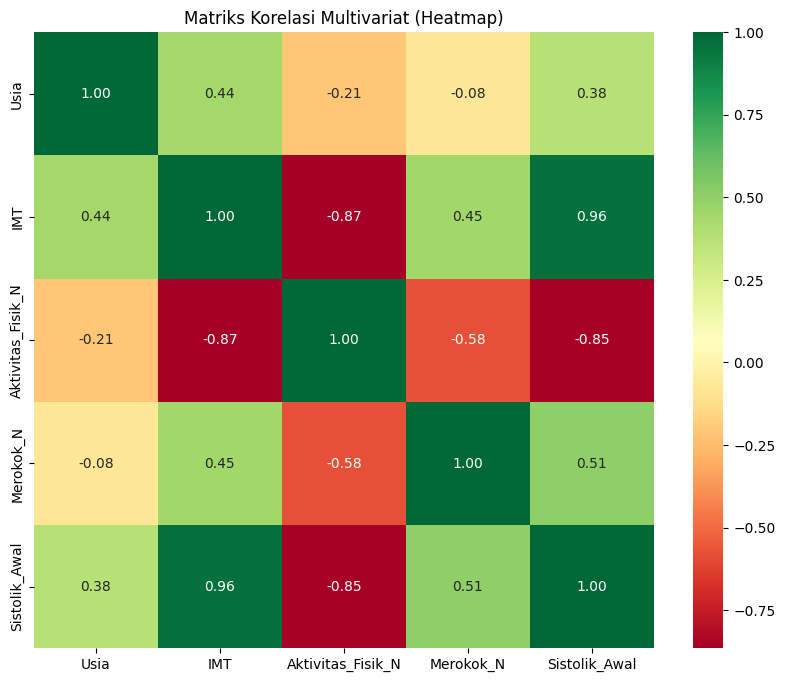

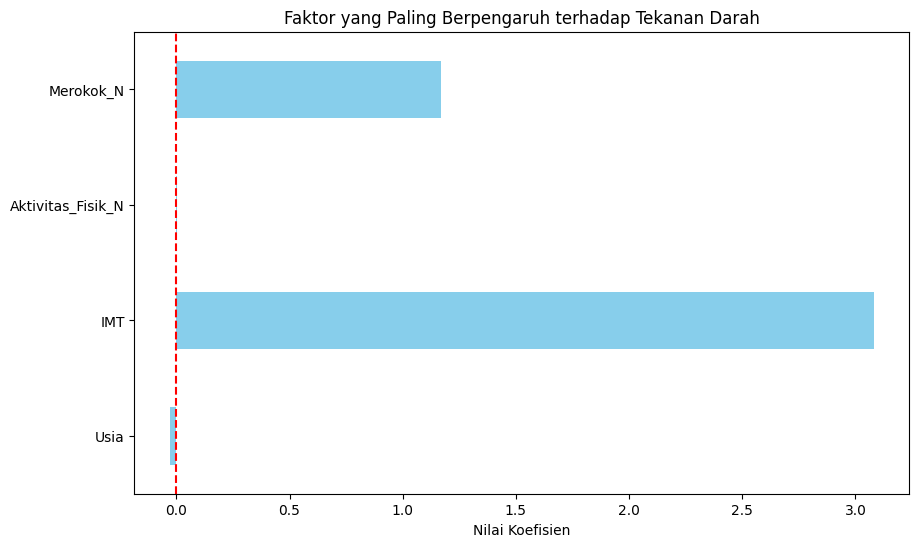

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder

# 1. Persiapan Data (Load & Merge)
demo = pd.read_csv(path + 'demografi_pasien.csv')
klinis = pd.read_csv(path + 'klinis_pasien.csv')
df = pd.merge(demo, klinis, on='ID_Pasien')

# 2. Pre-processing untuk Multivariat
# Kita harus mengubah data teks menjadi angka agar bisa dihitung mesin (Encoding)
le = LabelEncoder()
df['Jenis_Kelamin_N'] = le.fit_transform(df['Jenis_Kelamin'])
df['Merokok_N'] = le.fit_transform(df['Merokok'])
df['Aktivitas_Fisik_N'] = le.fit_transform(df['Aktivitas_Fisik'])
df['Sistolik_Awal'] = df['TD_Awal'].apply(lambda x: int(x.split('/')[0]))

# 3. Analisis Multivariat (Regresi Linear Berganda)
# Variabel Independen (X): Usia, IMT, Aktivitas, Merokok
# Variabel Dependen (y): Sistolik_Awal
X = df[['Usia', 'IMT', 'Aktivitas_Fisik_N', 'Merokok_N']]
y = df['Sistolik_Awal']

# Menambah konstanta (intercept)
X = sm.add_constant(X)

# Membuat Model
model = sm.OLS(y, X).fit()

# 4. Menampilkan Hasil Statistik Multivariat
print("=== HASIL ANALISIS MULTIVARIAT (REGRESI BERGANDA) ===")
print(model.summary())

# 5. Visualisasi: Heatmap Korelasi Multivariat
# Untuk melihat hubungan semua variabel dalam satu matriks
plt.figure(figsize=(10, 8))
corr_matrix = df[['Usia', 'IMT', 'Aktivitas_Fisik_N', 'Merokok_N', 'Sistolik_Awal']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Matriks Korelasi Multivariat (Heatmap)')
plt.show()

# 6. Visualisasi: Koefisien Pengaruh
plt.figure(figsize=(10, 6))
coefs = model.params[1:] # Ambil koefisien selain konstanta
coefs.plot(kind='barh', color='skyblue')
plt.axvline(0, color='red', linestyle='--')
plt.title('Faktor yang Paling Berpengaruh terhadap Tekanan Darah')
plt.xlabel('Nilai Koefisien')
plt.show()

# visualisasi data: dashboard matplotib

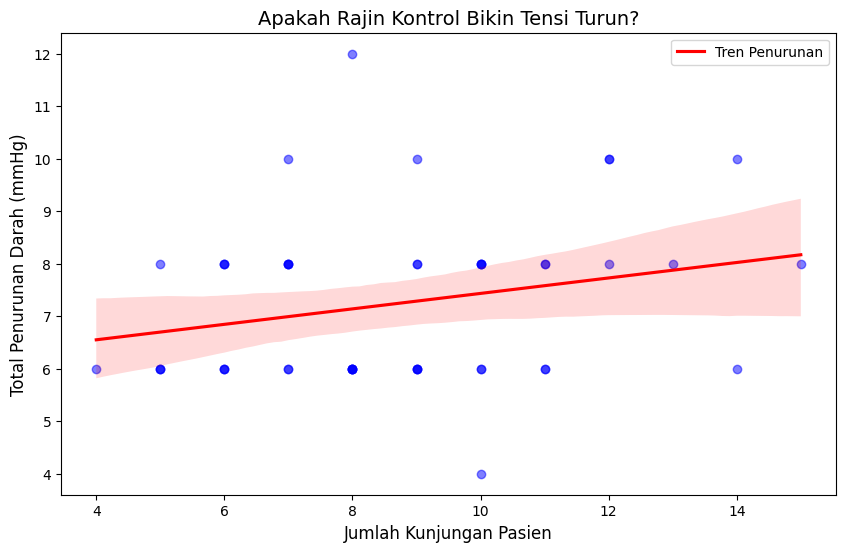

/tmp/ipykernel_4608/2846433066.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Metode_Pembayaran', y='Penurunan_Sistolik', data=df, palette='viridis')


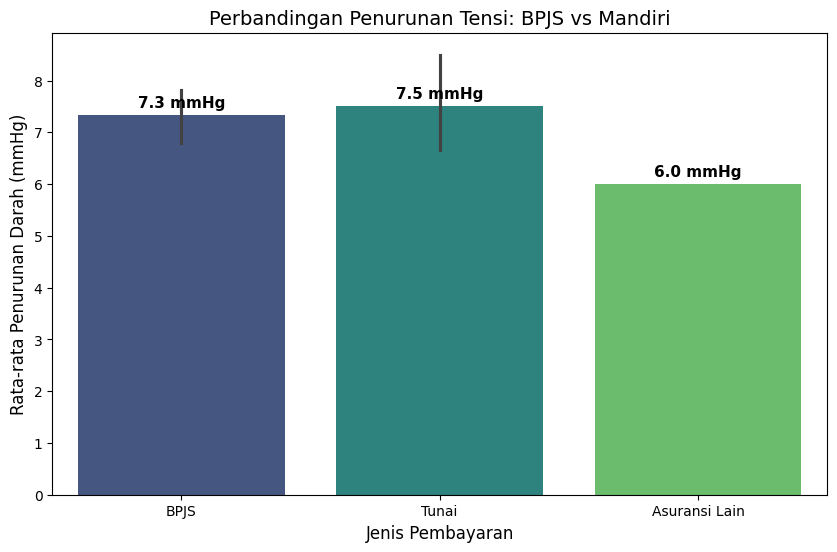

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA (Sesuaikan dengan nama file yang kamu upload)
df_demo = pd.read_csv(path + "demografi_pasien.csv")
df_klinis = pd.read_csv(path + "klinis_pasien.csv")
df_admin = pd.read_csv(path + "administratif_pasien.csv") # Ini data Kunjungan
df_keu = pd.read_csv(path + "keuangan_pasien.csv")       # Ini data BPJS/Metode Bayar

# 2. MERGING SEMUA DATA
df = pd.merge(df_demo, df_klinis, on='ID_Pasien')
df = pd.merge(df, df_admin[['ID_Pasien', 'Jumlah_Kunjungan']], on='ID_Pasien')
df = pd.merge(df, df_keu[['ID_Pasien', 'Metode_Pembayaran']], on='ID_Pasien')

# 3. HITUNG SELISIH PENURUNAN
df['Sistolik_Awal'] = df['TD_Awal'].apply(lambda x: int(x.split('/')[0]))
df['Sistolik_Akhir'] = df['TD_Akhir'].apply(lambda x: int(x.split('/')[0]))
df['Penurunan_Sistolik'] = df['Sistolik_Awal'] - df['Sistolik_Akhir']

# 4. VISUALISASI PERTANYAAN 4 (Kepatuhan)
plt.figure(figsize=(10, 6))
sns.regplot(x='Jumlah_Kunjungan', y='Penurunan_Sistolik', data=df,
            scatter_kws={'color': 'blue', 'alpha': 0.5},
            line_kws={'color': 'red', 'label': 'Tren Penurunan'})
plt.title('Apakah Rajin Kontrol Bikin Tensi Turun?', fontsize=14)
plt.xlabel('Jumlah Kunjungan Pasien', fontsize=12)
plt.ylabel('Total Penurunan Darah (mmHg)', fontsize=12)
plt.legend()
plt.show()

# 5. VISUALISASI PERTANYAAN 5 (Efektivitas Bayar)
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Metode_Pembayaran', y='Penurunan_Sistolik', data=df, palette='viridis')

# Tambahkan angka di atas batang agar mudah dibaca
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f} mmHg',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.title('Perbandingan Penurunan Tensi: BPJS vs Mandiri', fontsize=14)
plt.xlabel('Jenis Pembayaran', fontsize=12)
plt.ylabel('Rata-rata Penurunan Darah (mmHg)', fontsize=12)
plt.show()